# **ML Mini-Project: Loan Repayment Ability Prediction**

**Reference paper:** *Loanliness: Predicting Loan Repayment Ability by Using Machine Learning Methods*  
**Student:** PES1UG24CS149 PES1UG24CS170  
**Course:** UE24CS352A - Machine Learning

---

### **Objective**

The goal of this mini-project is to implement the main workflow described in the reference paper for predicting loan repayment ability using the Home Credit Default Risk dataset.

The project includes:

- Feature concatenation from the Home Credit data sources
- Invalid/empty entry handling
- Feature encoding and normalization
- Polynomial feature transformation
- Class balancing using down-sampling, up-sampling and class weights
- Logistic Regression
- Random Forest
- Naive Bayes
- LightGBM
- Neural Network / MLP
- ROC curves and classification metrics
- K-Means clustering and cluster-specific classification
- PCA and t-SNE visualization
- Random Forest feature-importance analysis

The coding style follows the ML lab notebooks: **numbered sections, short markdown explanations, direct scikit-learn code, explicit model initialization, `fit()` / `predict()` calls, printed results and plots.**

## **1. Problem Statement**

The problem is framed as a binary classification task.

We want to predict the repayment ability of a loan applicant from borrower/application information and historical loan information.

The reference paper highlights two major challenges:

1. The Home Credit dataset contains many missing or invalid entries.
2. The target classes are heavily imbalanced.

Therefore, accuracy alone is not sufficient for evaluating the classifiers.

## **2. Import Libraries and Setup**

First, let's import the libraries required for data manipulation, preprocessing, machine learning, evaluation and visualization.

In [ ]:
# Core libraries for data manipulation and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Libraries for machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

print("Libraries imported successfully.")

Libraries imported successfully.


## **3. Optional Libraries**

The paper uses **LightGBM** and discusses **SMOTE** for minority-class up-sampling.

These libraries are kept optional so that the notebook can still be opened and studied if they are not installed.

In [ ]:
# LightGBM
try:
    from lightgbm import LGBMClassifier
    LIGHTGBM_AVAILABLE = True
    print("LightGBM is available.")
except ImportError:
    LIGHTGBM_AVAILABLE = False
    print("LightGBM is not installed. Install it using: pip install lightgbm")

# SMOTE
try:
    from imblearn.over_sampling import SMOTE
    SMOTE_AVAILABLE = True
    print("SMOTE is available.")
except ImportError:
    SMOTE_AVAILABLE = False
    print("SMOTE is not installed. Install it using: pip install imbalanced-learn")

LightGBM is available.
SMOTE is available.


## **4. Dataset Setup**

Download the **Home Credit Default Risk** dataset and place the CSV files inside:

```text
data/home-credit-default-risk/
```

The reference paper uses these seven files:

- `application_train.csv`
- `bureau.csv`
- `bureau_balance.csv`
- `previous_application.csv`
- `POS_CASH_balance.csv`
- `installments_payments.csv`
- `credit_card_balance.csv`

In [ ]:
DATA_DIR = "sample_data"

APPLICATION_FILE = f"application_train.csv"
BUREAU_FILE = f"bureau.csv"
BUREAU_BALANCE_FILE = f"bureau_balance.csv"
PREVIOUS_FILE = f"previous_application.csv"
POS_CASH_FILE = f"POS_CASH_balance.csv"
INSTALLMENTS_FILE = f"installments_payments.csv"
CREDIT_CARD_FILE = f"credit_card_balance.csv"

print("Dataset directory:", DATA_DIR)

Dataset directory: sample_data


## **5. Load the Main Application Data**

`application_train.csv` contains the main applicant-level information and the `TARGET` column.

In the Home Credit dataset:

- `TARGET = 0` represents no default
- `TARGET = 1` represents default

In [ ]:
application = pd.read_csv(APPLICATION_FILE)

print("Application dataset shape:", application.shape)
display(application.head())

print("\nTarget distribution:")
print(application["TARGET"].value_counts())

print("\nTarget proportions:")
print(application["TARGET"].value_counts(normalize=True))

Application dataset shape: (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0



Target distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Target proportions:
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


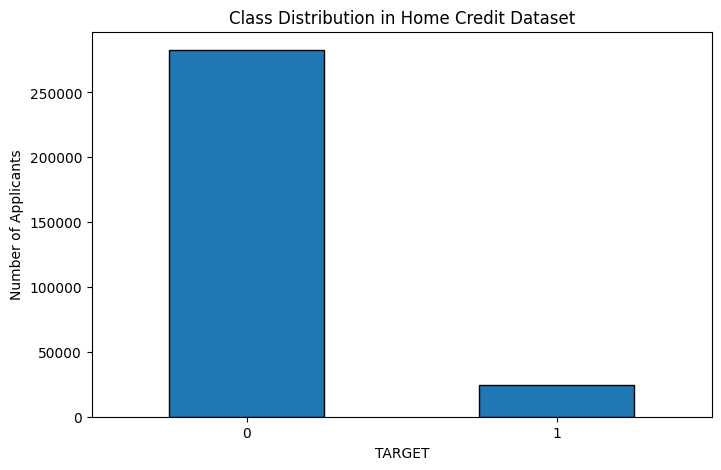

In [ ]:
plt.figure(figsize=(8, 5))

application["TARGET"].value_counts().sort_index().plot(
    kind="bar",
    edgecolor="black"
)

plt.xlabel("TARGET")
plt.ylabel("Number of Applicants")
plt.title("Class Distribution in Home Credit Dataset")
plt.xticks(rotation=0)
plt.show()

## **6. Load the Related Home Credit Tables**

The other files contain historical information about previous loans, bureau records, installments and credit cards.

Several of these files contain multiple rows for one applicant. Therefore, before merging them with the application table, we aggregate them to one row per `SK_ID_CURR`.

In [ ]:
bureau = pd.read_csv(BUREAU_FILE)
bureau_balance = pd.read_csv(BUREAU_BALANCE_FILE)
previous = pd.read_csv(PREVIOUS_FILE)
pos_cash = pd.read_csv(POS_CASH_FILE)
installments = pd.read_csv(INSTALLMENTS_FILE)
credit_card = pd.read_csv(CREDIT_CARD_FILE)

print("bureau:", bureau.shape)
print("bureau_balance:", bureau_balance.shape)
print("previous_application:", previous.shape)
print("POS_CASH_balance:", pos_cash.shape)
print("installments_payments:", installments.shape)
print("credit_card_balance:", credit_card.shape)

bureau: (1716428, 17)
bureau_balance: (18829755, 3)
previous_application: (344265, 37)
POS_CASH_balance: (2347629, 8)
installments_payments: (4419340, 8)
credit_card_balance: (2452181, 23)


### **6.1 Feature Concatenation**

The paper concatenates information from the different sources before training the models.

The helper below creates applicant-level aggregate features from the historical tables.

In [ ]:
def aggregate_by_customer(data, customer_column="SK_ID_CURR", prefix=""):
    data = data.copy()

    numeric_columns = data.select_dtypes(include=np.number).columns.tolist()

    if customer_column in numeric_columns:
        numeric_columns.remove(customer_column)

    if len(numeric_columns) == 0:
        return data[[customer_column]].drop_duplicates()

    aggregated = data.groupby(customer_column)[numeric_columns].agg(
        ["count", "mean", "min", "max"]
    )

    aggregated.columns = [
        f"{prefix}{column}_{stat}"
        for column, stat in aggregated.columns
    ]

    aggregated = aggregated.reset_index()

    return aggregated

### **6.2 Aggregate `bureau_balance.csv`**

`bureau_balance.csv` is indexed by `SK_ID_BUREAU`, so it is first aggregated at bureau level and then joined to `bureau.csv`.

In [ ]:
bb_numeric = bureau_balance.select_dtypes(include=np.number).columns.tolist()

if "SK_ID_BUREAU" in bb_numeric:
    bb_numeric.remove("SK_ID_BUREAU")

if len(bb_numeric) > 0:

    bb_agg = bureau_balance.groupby("SK_ID_BUREAU")[bb_numeric].agg(
        ["count", "mean", "min", "max"]
    )

    bb_agg.columns = [
        f"BB_{column}_{stat}"
        for column, stat in bb_agg.columns
    ]

    bb_agg = bb_agg.reset_index()

    bureau_full = bureau.merge(
        bb_agg,
        on="SK_ID_BUREAU",
        how="left"
    )

else:
    bureau_full = bureau.copy()

print("Combined bureau table shape:", bureau_full.shape)

Combined bureau table shape: (1716428, 21)


### **6.3 Aggregate Historical Tables and Merge**

Now we create applicant-level summaries and merge them with the application table.

In [ ]:
bureau_agg = aggregate_by_customer(
    bureau_full,
    customer_column="SK_ID_CURR",
    prefix="BUREAU_"
)

previous_agg = aggregate_by_customer(
    previous,
    customer_column="SK_ID_CURR",
    prefix="PREV_"
)

pos_cash_agg = aggregate_by_customer(
    pos_cash,
    customer_column="SK_ID_CURR",
    prefix="POS_"
)

installments_agg = aggregate_by_customer(
    installments,
    customer_column="SK_ID_CURR",
    prefix="INST_"
)

credit_card_agg = aggregate_by_customer(
    credit_card,
    customer_column="SK_ID_CURR",
    prefix="CC_"
)

data = application.copy()

for table in [
    bureau_agg,
    previous_agg,
    pos_cash_agg,
    installments_agg,
    credit_card_agg
]:
    data = data.merge(
        table,
        on="SK_ID_CURR",
        how="left"
    )

print("Combined dataset shape:", data.shape)
display(data.head())

Combined dataset shape: (307511, 402)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,CC_CNT_INSTALMENT_MATURE_CUM_min,CC_CNT_INSTALMENT_MATURE_CUM_max,CC_SK_DPD_count,CC_SK_DPD_mean,CC_SK_DPD_min,CC_SK_DPD_max,CC_SK_DPD_DEF_count,CC_SK_DPD_DEF_mean,CC_SK_DPD_DEF_min,CC_SK_DPD_DEF_max
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.0,0.0,6.0,0.0,0.0,0.0,6.0,0.0,0.0,0.0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## **7. Inspect the Combined Dataset**

In [ ]:
print("Dataset shape:", data.shape)
print("Duplicate rows:", data.duplicated().sum())

print("\nNumerical features:",
      len(data.select_dtypes(include=np.number).columns))

print("Categorical features:",
      len(data.select_dtypes(exclude=np.number).columns))

print("\nMissing values:")
missing_percentage = (
    data.isnull()
        .mean()
        .sort_values(ascending=False)
        .mul(100)
)

display(missing_percentage.head(20).to_frame("Missing Percentage"))

Dataset shape: (307511, 402)
Duplicate rows: 0

Numerical features: 386
Categorical features: 16

Missing values:


,Missing Percentage
PREV_RATE_INTEREST_PRIMARY_max,99.678385
PREV_RATE_INTEREST_PRIVILEGED_max,99.678385
PREV_RATE_INTEREST_PRIVILEGED_min,99.678385
PREV_RATE_INTEREST_PRIMARY_min,99.678385
PREV_RATE_INTEREST_PRIMARY_mean,99.678385
PREV_RATE_INTEREST_PRIVILEGED_mean,99.678385
CC_AMT_PAYMENT_CURRENT_min,80.253715
CC_AMT_PAYMENT_CURRENT_mean,80.253715
CC_AMT_PAYMENT_CURRENT_max,80.253715
CC_CNT_DRAWINGS_OTHER_CURRENT_mean,80.226398


## **8. Invalid / Empty Entry Replacement**

The reference paper uses a **30% threshold**.

If a feature contains more than 30% invalid/empty entries, the feature is removed.

For the remaining features, missing numerical values are replaced with the feature mean and categorical values are handled separately.

In [ ]:
MISSING_THRESHOLD = 0.30

missing_ratio = data.isnull().mean()

columns_to_drop = missing_ratio[
    missing_ratio > MISSING_THRESHOLD
].index.tolist()

data_clean = data.drop(
    columns=columns_to_drop
)

print("Columns before removal:", data.shape[1])
print("Columns removed:", len(columns_to_drop))
print("Columns after removal:", data_clean.shape[1])

Columns before removal: 402
Columns removed: 256
Columns after removal: 146


## **9. Remove the Applicant ID from the Predictive Features**

`SK_ID_CURR` identifies the applicant and should not be used as a predictive feature.

The target variable is separated from the input features.

In [ ]:
X = data_clean.drop(
    columns=["TARGET", "SK_ID_CURR"],
    errors="ignore"
)

y = data_clean["TARGET"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (307511, 144)
Target shape: (307511,)


## **10. Train-Test Split**

We use a stratified split so that the class proportions are preserved in both the training and testing sets.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training set: (246008, 144)
Testing set: (61503, 144)

Training target distribution:
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

Testing target distribution:
TARGET
0    0.919272
1    0.080728
Name: proportion, dtype: float64


## **11. Feature Encoding and Normalization**

The paper describes two types of categorical processing:

- Label/factorization for categorical values
- One-hot encoding where appropriate

For a robust implementation, we use `OneHotEncoder` for categorical features and `StandardScaler` for numerical features.

Missing values are also handled inside the preprocessing pipeline.

In [ ]:
numeric_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X_train.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Number of numerical features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

Number of numerical features: 133
Number of categorical features: 11


In [ ]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


## **12. Transform the Data**

We fit the preprocessing steps only on the training data and then transform both training and testing data.

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (246008, 239)
Processed testing shape: (61503, 239)


## **13. Class Imbalance**

The reference paper investigates three approaches:

1. Down-sampling the majority class
2. Up-sampling the minority class using techniques such as SMOTE
3. Using class weights

We first create a down-sampled training set.

In [ ]:
train_data = pd.DataFrame(
    X_train_processed
)

train_data["TARGET"] = y_train.to_numpy()

majority_class = train_data[
    train_data["TARGET"] == 0
]

minority_class = train_data[
    train_data["TARGET"] == 1
]

print("Majority class:", len(majority_class))
print("Minority class:", len(minority_class))

Majority class: 226148
Minority class: 19860


In [ ]:
majority_downsampled = majority_class.sample(
    n=len(minority_class),
    random_state=42
)

balanced_downsampled = pd.concat(
    [majority_downsampled, minority_class]
)

balanced_downsampled = balanced_downsampled.sample(
    frac=1,
    random_state=42
)

X_train_down = balanced_downsampled.drop(
    columns=["TARGET"]
).values

y_train_down = balanced_downsampled["TARGET"].values

print("Down-sampled training shape:", X_train_down.shape)
print("\nBalanced target distribution:")
print(pd.Series(y_train_down).value_counts())

Down-sampled training shape: (39720, 239)

Balanced target distribution:
1    19860
0    19860
Name: count, dtype: int64


### **13.1 Up-sampling with SMOTE**

SMOTE generates synthetic minority-class examples.

This experiment is performed only when `imbalanced-learn` is available.

In [ ]:
if SMOTE_AVAILABLE:

    smote = SMOTE(
        random_state=42
    )

    X_train_smote, y_train_smote = smote.fit_resample(
        X_train_processed,
        y_train
    )

    print("SMOTE training shape:", X_train_smote.shape)
    print("\nSMOTE target distribution:")
    print(pd.Series(y_train_smote).value_counts())

else:

    X_train_smote = None
    y_train_smote = None

    print("SMOTE experiment skipped.")

SMOTE training shape: (452296, 239)

SMOTE target distribution:
TARGET
0    226148
1    226148
Name: count, dtype: int64


## **14. Evaluation Function**

The reference paper compares classifiers using accuracy, precision, recall and F1-score and also uses ROC/AUC analysis.

The following function prints the main classification metrics.

In [ ]:
def evaluate_model(model, X_test, y_test, model_name):

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )
    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )
    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )
    auc = roc_auc_score(
        y_test,
        y_prob
    )

    print("\n" + "=" * 60)
    print(model_name)
    print("=" * 60)

    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))
    print("ROC-AUC  :", round(auc, 4))

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            y_pred,
            zero_division=0
        )
    )

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": auc
    }

# **PART A — Classification on the Down-Sampled Dataset**

The reference paper reports that the down-sampled dataset produced its best overall classifier performance.

We therefore train the main models on the balanced training set.

## **15. Logistic Regression**

Logistic Regression is used as a linear classification baseline.

In [ ]:
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logistic_model.fit(
    X_train_down,
    y_train_down
)

logistic_result = evaluate_model(
    logistic_model,
    X_test_processed,
    y_test,
    "Logistic Regression"
)


Logistic Regression
Accuracy : 0.6929
Precision: 0.1642
Recall   : 0.6856
F1 Score : 0.265
ROC-AUC  : 0.7546

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.69      0.81     56538
           1       0.16      0.69      0.26      4965

    accuracy                           0.69     61503
   macro avg       0.56      0.69      0.54     61503
weighted avg       0.90      0.69      0.76     61503



## **16. Random Forest**

Random Forest is a tree-based ensemble method.

It is also used later for feature-importance analysis.

In [ ]:
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(
    X_train_down,
    y_train_down
)

random_forest_result = evaluate_model(
    random_forest_model,
    X_test_processed,
    y_test,
    "Random Forest"
)


Random Forest
Accuracy : 0.6966
Precision: 0.1641
Recall   : 0.6735
F1 Score : 0.2639
ROC-AUC  : 0.7453

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.70      0.81     56538
           1       0.16      0.67      0.26      4965

    accuracy                           0.70     61503
   macro avg       0.56      0.69      0.54     61503
weighted avg       0.90      0.70      0.76     61503



## **17. Naive Bayes**

Gaussian Naive Bayes provides a probabilistic classification approach for comparison with the other models.

In [ ]:
naive_bayes_model = GaussianNB()

naive_bayes_model.fit(
    X_train_down,
    y_train_down
)

naive_bayes_result = evaluate_model(
    naive_bayes_model,
    X_test_processed,
    y_test,
    "Naive Bayes"
)


Naive Bayes
Accuracy : 0.3388
Precision: 0.0959
Recall   : 0.8528
F1 Score : 0.1724
ROC-AUC  : 0.645

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.29      0.45     56538
           1       0.10      0.85      0.17      4965

    accuracy                           0.34     61503
   macro avg       0.53      0.57      0.31     61503
weighted avg       0.89      0.34      0.43     61503



## **18. Neural Network / MLP**

The paper uses a multi-layer perceptron neural network.

This also connects directly with the ANN concepts implemented in the ML lab.

In [ ]:
mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    max_iter=50,
    early_stopping=True,
    random_state=42
)

mlp_model.fit(
    X_train_down,
    y_train_down
)

mlp_result = evaluate_model(
    mlp_model,
    X_test_processed,
    y_test,
    "MLP Neural Network"
)


MLP Neural Network
Accuracy : 0.6964
Precision: 0.1638
Recall   : 0.6729
F1 Score : 0.2635
ROC-AUC  : 0.7486

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.70      0.81     56538
           1       0.16      0.67      0.26      4965

    accuracy                           0.70     61503
   macro avg       0.56      0.69      0.54     61503
weighted avg       0.90      0.70      0.76     61503



## **19. LightGBM**

LightGBM is the gradient-boosting tree classifier used in the reference paper.

If LightGBM is unavailable, this section is skipped.

In [ ]:
if LIGHTGBM_AVAILABLE:

    lightgbm_model = LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42,
        verbosity=-1
    )

    lightgbm_model.fit(
        X_train_down,
        y_train_down
    )

    lightgbm_result = evaluate_model(
        lightgbm_model,
        X_test_processed,
        y_test,
        "LightGBM"
    )

else:

    lightgbm_model = None
    lightgbm_result = None

    print("LightGBM experiment skipped.")


LightGBM
Accuracy : 0.6967
Precision: 0.1678
Recall   : 0.6961
F1 Score : 0.2704
ROC-AUC  : 0.7617

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.70      0.81     56538
           1       0.17      0.70      0.27      4965

    accuracy                           0.70     61503
   macro avg       0.57      0.70      0.54     61503
weighted avg       0.90      0.70      0.77     61503



## **20. Compare All Classifiers**

The results from all models are collected into a single table.

In [51]:
results = [
    logistic_result,
    random_forest_result,
    naive_bayes_result,
    mlp_result
]

if lightgbm_result is not None:
    results.append(lightgbm_result)

results_df = pd.DataFrame(results)

display(
    results_df.sort_values(
        by="ROC-AUC",
        ascending=False
    )
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
4,LightGBM,0.696714,0.167767,0.696073,0.270370,0.761655
0,Logistic Regression,0.692909,0.164206,0.685599,0.264954,0.754638
3,MLP Neural Network,0.696373,0.163847,0.672910,0.263527,0.748565
1,Random Forest,0.696616,0.164066,0.673515,0.263858,0.745284
2,Naive Bayes,0.338829,0.095863,0.852769,0.172352,0.644982


## **21. ROC Curves**

ROC curves are used in the paper to compare the ability of the classifiers to distinguish the two classes.

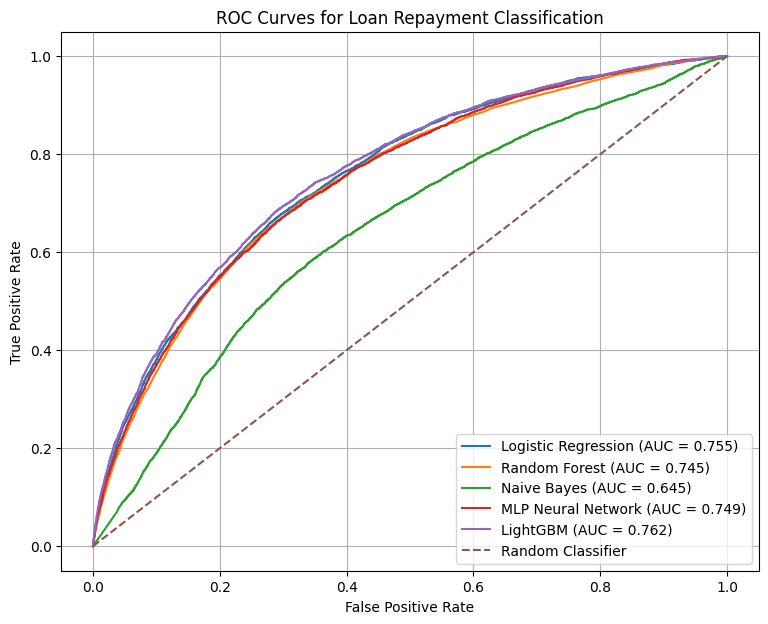

In [52]:
models_for_roc = [
    ("Logistic Regression", logistic_model),
    ("Random Forest", random_forest_model),
    ("Naive Bayes", naive_bayes_model),
    ("MLP Neural Network", mlp_model)
]

if lightgbm_model is not None:
    models_for_roc.append(
        ("LightGBM", lightgbm_model)
    )

plt.figure(figsize=(9, 7))

for model_name, model in models_for_roc:

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_processed)[:, 1]
    else:
        y_prob = model.decision_function(X_test_processed)

    fpr, tpr, _ = roc_curve(
        y_test,
        y_prob
    )

    auc = roc_auc_score(
        y_test,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC = {auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Loan Repayment Classification")
plt.legend()
plt.grid(True)
plt.show()

## **22. Confusion Matrix for the Best Model**

We select the model with the highest ROC-AUC on our experiment and inspect its confusion matrix.

Best model based on ROC-AUC: LightGBM


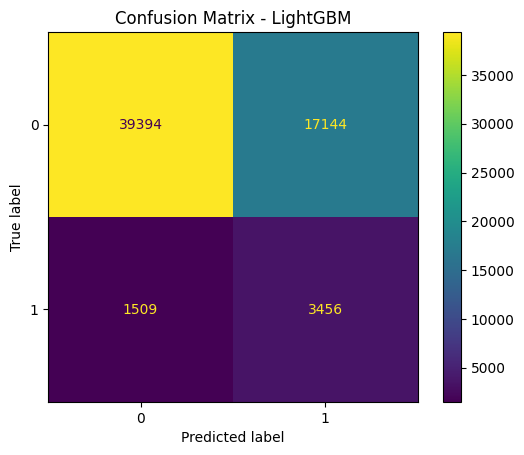

In [ ]:
best_model_name = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).iloc[0]["Model"]

best_model_lookup = {
    "Logistic Regression": logistic_model,
    "Random Forest": random_forest_model,
    "Naive Bayes": naive_bayes_model,
    "MLP Neural Network": mlp_model
}

if lightgbm_model is not None:
    best_model_lookup["LightGBM"] = lightgbm_model

best_model = best_model_lookup[best_model_name]

print("Best model based on ROC-AUC:", best_model_name)

y_best_pred = best_model.predict(
    X_test_processed
)

cm = confusion_matrix(
    y_test,
    y_best_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

# **PART B — Class-Balancing Experiments**

The paper compares different ways of dealing with class imbalance.

Here we compare:

- Original imbalanced training data
- Down-sampling
- SMOTE
- Class-weighted models

## **23. Baseline: Train on the Original Imbalanced Data**

This provides a baseline for understanding the effect of balancing.

In [ ]:
baseline_logistic = LogisticRegression(
    random_state=42,
    max_iter=1000
)

baseline_logistic.fit(
    X_train_processed,
    y_train
)

baseline_result = evaluate_model(
    baseline_logistic,
    X_test_processed,
    y_test,
    "Logistic Regression - Original Data"
)


Logistic Regression - Original Data
Accuracy : 0.9195
Precision: 0.5532
Recall   : 0.0157
F1 Score : 0.0306
ROC-AUC  : 0.7545

Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.55      0.02      0.03      4965

    accuracy                           0.92     61503
   macro avg       0.74      0.51      0.49     61503
weighted avg       0.89      0.92      0.88     61503



## **24. Class Weights**

The paper uses class weights based on the inverse frequency of the classes.

For scikit-learn, `class_weight="balanced"` implements this idea automatically.

In [ ]:
weighted_logistic = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

weighted_logistic.fit(
    X_train_processed,
    y_train
)

weighted_result = evaluate_model(
    weighted_logistic,
    X_test_processed,
    y_test,
    "Logistic Regression - Class Weights"
)

## **25. Compare Balancing Strategies**

SMOTE is included only when the package is available.

In [43]:
balance_results = [
    baseline_result,
    weighted_result,
    logistic_result
]

if SMOTE_AVAILABLE:

    smote_logistic = LogisticRegression(
        random_state=42,
        max_iter=1000
    )

    smote_logistic.fit(
        X_train_smote,
        y_train_smote
    )

    smote_result = evaluate_model(
        smote_logistic,
        X_test_processed,
        y_test,
        "Logistic Regression - SMOTE"
    )

    balance_results.append(
        smote_result
    )

balance_df = pd.DataFrame(balance_results)

display(balance_df)


Logistic Regression - SMOTE
Accuracy : 0.6977
Precision: 0.164
Recall   : 0.6699
F1 Score : 0.2635
ROC-AUC  : 0.7508

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.70      0.81     56538
           1       0.16      0.67      0.26      4965

    accuracy                           0.70     61503
   macro avg       0.56      0.69      0.54     61503
weighted avg       0.90      0.70      0.77     61503



,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression - Original Data,0.919516,0.553191,0.015710,0.030552,0.754493
1,Logistic Regression - Class Weights,0.693999,0.164284,0.682779,0.264844,0.755764
2,Logistic Regression,0.692909,0.164206,0.685599,0.264954,0.754638
3,Logistic Regression - SMOTE,0.697722,0.164020,0.669889,0.263519,0.750804


# **PART C — Polynomial Feature Transformation**

The paper applies polynomial feature transformation to obtain polynomial combinations of the input features for linear classifiers.

Because the full Home Credit feature space is very large, applying polynomial expansion to every processed feature can become computationally impractical.

Therefore, we demonstrate the transformation on a controlled subset of the processed features.

In [44]:
POLY_FEATURE_COUNT = min(10, X_train_down.shape[1])

X_poly_train_base = X_train_down[:, :POLY_FEATURE_COUNT]
X_poly_test_base = X_test_processed[:, :POLY_FEATURE_COUNT]

print("Features selected for polynomial demonstration:",
      POLY_FEATURE_COUNT)

Features selected for polynomial demonstration: 10


In [45]:
poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)

X_poly_train = poly.fit_transform(
    X_poly_train_base
)

X_poly_test = poly.transform(
    X_poly_test_base
)

print("Original selected feature count:", POLY_FEATURE_COUNT)
print("Polynomial feature count:", X_poly_train.shape[1])

Original selected feature count: 10
Polynomial feature count: 65


## **26. Logistic Regression with Polynomial Features**

In [46]:
poly_logistic = LogisticRegression(
    random_state=42,
    max_iter=1000
)

poly_logistic.fit(
    X_poly_train,
    y_train_down
)

poly_pred = poly_logistic.predict(
    X_poly_test
)

poly_prob = poly_logistic.predict_proba(
    X_poly_test
)[:, 1]

print("Accuracy :", round(
    accuracy_score(y_test, poly_pred), 4
))

print("Precision:", round(
    precision_score(y_test, poly_pred, zero_division=0), 4
))

print("Recall   :", round(
    recall_score(y_test, poly_pred, zero_division=0), 4
))

print("F1 Score :", round(
    f1_score(y_test, poly_pred, zero_division=0), 4
))

print("ROC-AUC  :", round(
    roc_auc_score(y_test, poly_prob), 4
))

Accuracy : 0.596
Precision: 0.116
Recall   : 0.605
F1 Score : 0.1947
ROC-AUC  : 0.6429


# **PART D — K-Means Clustering**

The paper uses K-Means to identify groups of borrowers and then trains separate classifiers for each cluster.

Several values of `k` are explored before using `k = 4`.

## **27. Prepare Data for Clustering**

Clustering is computationally expensive on the complete high-dimensional dataset, so we use the balanced training data and apply PCA before K-Means.

The PCA step is used only to make the clustering computation manageable; it does not replace the paper's PCA visualization later.

In [47]:
CLUSTER_SAMPLE_SIZE = min(30000, len(X_train_down))

cluster_indices = np.random.choice(
    len(X_train_down),
    size=CLUSTER_SAMPLE_SIZE,
    replace=False
)

X_cluster_sample = X_train_down[
    cluster_indices
]

y_cluster_sample = y_train_down[
    cluster_indices
]

cluster_pca = PCA(
    n_components=min(20, X_cluster_sample.shape[1]),
    random_state=42
)

X_cluster_reduced = cluster_pca.fit_transform(
    X_cluster_sample
)

print("Clustering data shape:", X_cluster_reduced.shape)

Clustering data shape: (30000, 20)


## **28. Experiment with Different Values of K**

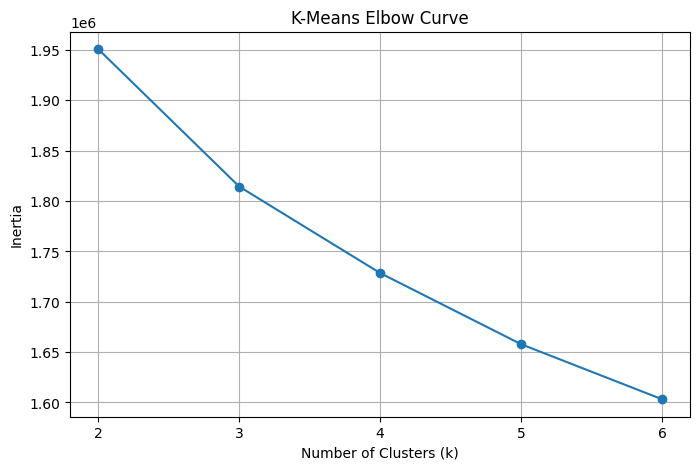

In [48]:
k_values = [2, 3, 4, 5, 6]
k_inertia = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(
        X_cluster_reduced
    )

    k_inertia.append(
        kmeans.inertia_
    )

plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    k_inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("K-Means Elbow Curve")
plt.xticks(k_values)
plt.grid(True)
plt.show()

## **29. K-Means with k = 4**

The reference paper reports that `k = 4` produced the best overall cluster-specific classification result.

In [49]:
kmeans_4 = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans_4.fit_predict(
    X_cluster_reduced
)

print("Cluster distribution:")
print(
    pd.Series(cluster_labels)
    .value_counts()
    .sort_index()
)

Cluster distribution:
0     5075
1     3626
2    12251
3     9048
Name: count, dtype: int64


## **30. Visualize the Four Clusters**

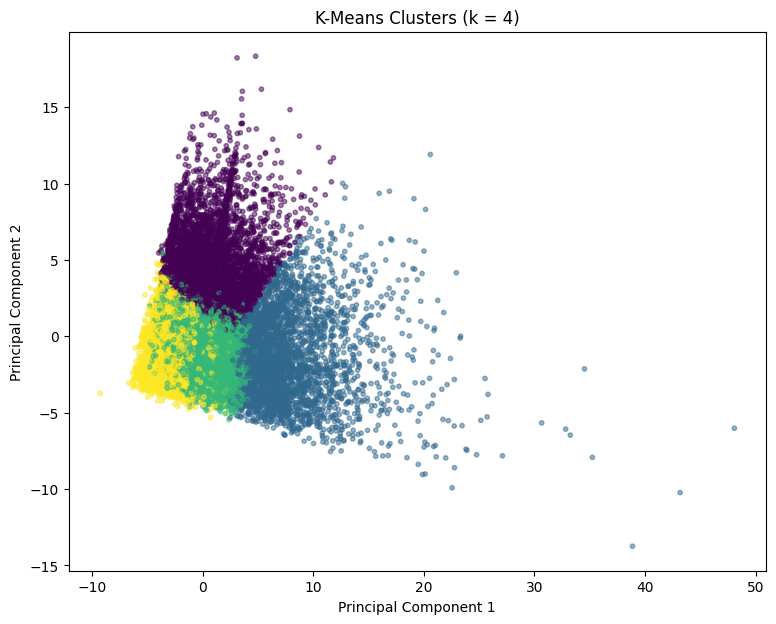

In [50]:
plt.figure(figsize=(9, 7))

plt.scatter(
    X_cluster_reduced[:, 0],
    X_cluster_reduced[:, 1],
    c=cluster_labels,
    s=10,
    alpha=0.5
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters (k = 4)")
plt.show()

## **31. Cluster-Specific LightGBM Classification**

The paper trains separate prediction models for the clusters.

We use LightGBM for this experiment when it is available because the paper reports LightGBM as the strongest model within the cluster experiments.

In [53]:
if LIGHTGBM_AVAILABLE:

    cluster_models = {}
    cluster_results = []

    for cluster_id in sorted(np.unique(cluster_labels)):

        cluster_mask = (
            cluster_labels == cluster_id
        )

        X_cluster_train = X_cluster_sample[
            cluster_mask
        ]

        y_cluster_train = y_cluster_sample[
            cluster_mask
        ]

        cluster_model = LGBMClassifier(
            n_estimators=150,
            learning_rate=0.05,
            num_leaves=31,
            random_state=42,
            verbosity=-1
        )

        cluster_model.fit(
            X_cluster_train,
            y_cluster_train
        )

        cluster_models[cluster_id] = cluster_model

        print(
            f"Cluster {cluster_id + 1}: "
            f"{len(y_cluster_train)} samples"
        )

    print("\nCluster-specific models trained.")

else:

    cluster_models = None
    print("LightGBM is not available; cluster-specific classification skipped.")

Cluster 1: 5075 samples
Cluster 2: 3626 samples
Cluster 3: 12251 samples
Cluster 4: 9048 samples

Cluster-specific models trained.


# **PART E — PCA Visualization**

The reference paper uses PCA to visualize the high-dimensional dataset in two dimensions.

We use a representative sample for visualization so that the notebook remains practical to run.

## **32. PCA for Visualization**

In [54]:
PCA_SAMPLE_SIZE = min(
    10000,
    len(X_train_down)
)

pca_indices = np.random.choice(
    len(X_train_down),
    size=PCA_SAMPLE_SIZE,
    replace=False
)

X_pca_sample = X_train_down[
    pca_indices
]

y_pca_sample = y_train_down[
    pca_indices
]

pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(
    X_pca_sample
)

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print(
    "Total variance explained by first two components:",
    round(pca.explained_variance_ratio_.sum(), 4)
)

Explained variance ratio:
[0.12329433 0.11430346]
Total variance explained by first two components: 0.2376


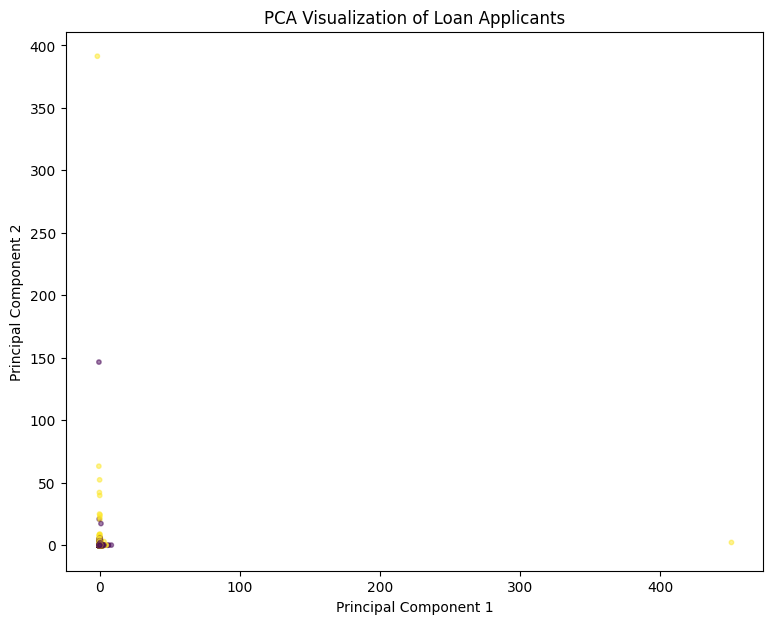

In [55]:
plt.figure(figsize=(9, 7))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y_pca_sample,
    s=10,
    alpha=0.5
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Loan Applicants")
plt.show()

# **PART F — t-SNE Visualization**

t-SNE is another dimensionality-reduction technique used by the reference paper.

Since t-SNE is computationally expensive, we use a smaller sample.

## **33. t-SNE on the Original Processed Features**

In [56]:
TSNE_SAMPLE_SIZE = min(
    3000,
    len(X_train_down)
)

tsne_indices = np.random.choice(
    len(X_train_down),
    size=TSNE_SAMPLE_SIZE,
    replace=False
)

X_tsne_sample = X_train_down[
    tsne_indices
]

y_tsne_sample = y_train_down[
    tsne_indices
]

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    init="pca"
)

X_tsne = tsne.fit_transform(
    X_tsne_sample
)

print("t-SNE transformation completed.")

t-SNE transformation completed.


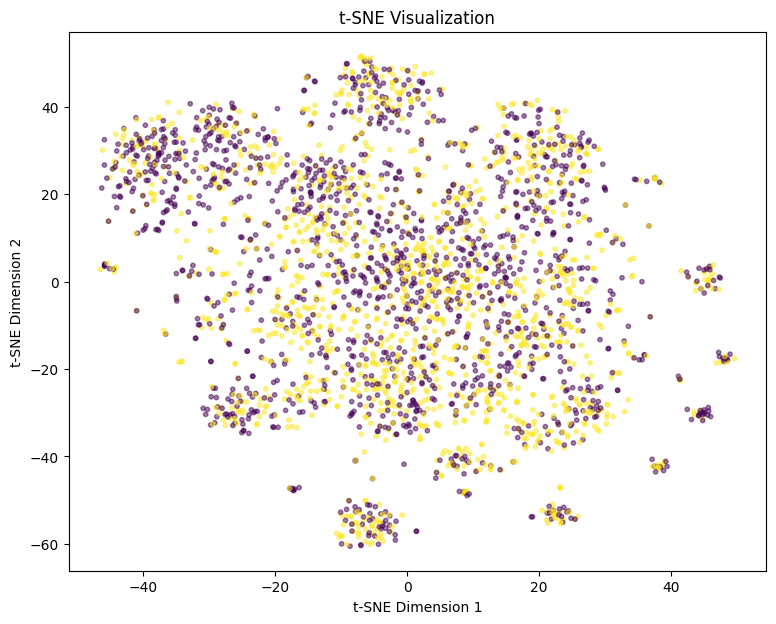

In [57]:
plt.figure(figsize=(9, 7))

plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y_tsne_sample,
    s=10,
    alpha=0.5
)

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("t-SNE Visualization")
plt.show()

## **34. t-SNE After PCA**

The paper also investigates applying PCA before t-SNE.

We reduce the data to a moderate number of principal components first and then apply t-SNE.

In [58]:
pca_for_tsne = PCA(
    n_components=min(30, X_tsne_sample.shape[1]),
    random_state=42
)

X_tsne_pca = pca_for_tsne.fit_transform(
    X_tsne_sample
)

print("Shape after PCA:", X_tsne_pca.shape)

tsne_after_pca = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    init="pca"
)

X_tsne_after_pca = tsne_after_pca.fit_transform(
    X_tsne_pca
)

print("t-SNE after PCA completed.")

Shape after PCA: (3000, 30)
t-SNE after PCA completed.


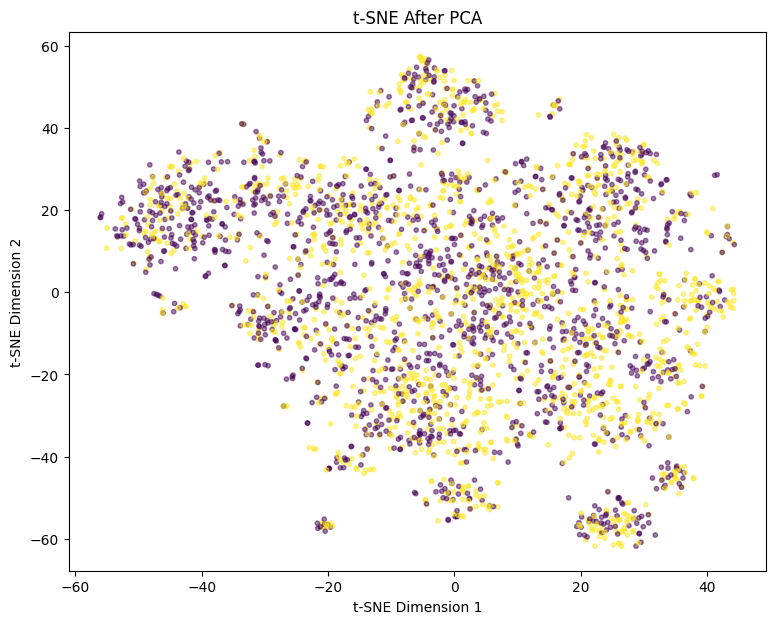

In [59]:
plt.figure(figsize=(9, 7))

plt.scatter(
    X_tsne_after_pca[:, 0],
    X_tsne_after_pca[:, 1],
    c=y_tsne_sample,
    s=10,
    alpha=0.5
)

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("t-SNE After PCA")
plt.show()

# **PART G — Feature Importance Analysis**

The reference paper uses Random Forest feature importance to identify the most influential features.

The preprocessing step may expand categorical variables through one-hot encoding, so we recover the processed feature names before plotting the importance scores.

## **35. Extract Processed Feature Names**

In [60]:
try:

    feature_names = preprocessor.get_feature_names_out()

except Exception:

    feature_names = np.array([
        f"Feature_{i}"
        for i in range(X_train_processed.shape[1])
    ])

print("Number of processed feature names:", len(feature_names))

Number of processed feature names: 239


## **36. Random Forest Feature Importance**

In [61]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(
    feature_importance.head(20)
)

,Feature,Importance
26,num__EXT_SOURCE_2,0.050583
27,num__EXT_SOURCE_3,0.040822
6,num__DAYS_BIRTH,0.022874
7,num__DAYS_EMPLOYED,0.019483
9,num__DAYS_ID_PUBLISH,0.018641
8,num__DAYS_REGISTRATION,0.018208
2,num__AMT_CREDIT,0.018094
3,num__AMT_ANNUITY,0.018012
4,num__AMT_GOODS_PRICE,0.017580
32,num__DAYS_LAST_PHONE_CHANGE,0.017100


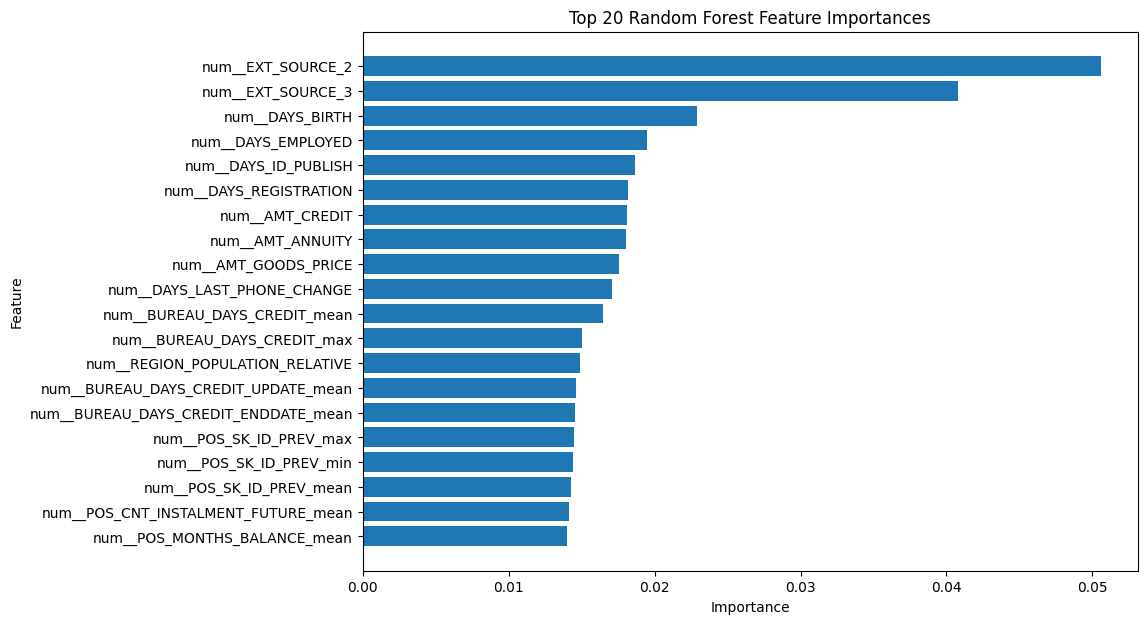

In [62]:
top_features = feature_importance.head(20)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"].iloc[::-1],
    top_features["Importance"].iloc[::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Random Forest Feature Importances")
plt.show()

# **PART H — Final Results**

The following table provides a compact summary of the main supervised-learning experiments.

The actual values must be obtained by running the notebook on the Home Credit dataset. They should not be copied from the reference paper because they correspond to our implementation.

In [63]:
final_results = results_df.copy()

final_results = final_results.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

display(final_results)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,LightGBM,0.696714,0.167767,0.696073,0.270370,0.761655
1,Logistic Regression,0.692909,0.164206,0.685599,0.264954,0.754638
2,MLP Neural Network,0.696373,0.163847,0.672910,0.263527,0.748565
3,Random Forest,0.696616,0.164066,0.673515,0.263858,0.745284
4,Naive Bayes,0.338829,0.095863,0.852769,0.172352,0.644982


## **37. Reference Paper Results**

For comparison only, the paper reports approximately:

| Classifier | Accuracy |
|---|---:|
| Logistic Regression | 69.34% |
| Random Forest | 63.51% |
| Naive Bayes | 52.11% |
| MLP | 62.34% |
| LightGBM | 57.47% |

These are **reported paper results**, not results produced by this notebook.

Our results should be discussed separately because preprocessing, feature aggregation, package versions and experimental settings may differ.

# **38. Conclusion**

From this implementation, we should discuss:

1. How missing/invalid values affected the dataset.
2. How the class imbalance affected the classifiers.
3. Which balancing strategy performed best.
4. Which classifier achieved the best performance in our experiment.
5. What the ROC curves tell us about class separation.
6. Whether K-Means reveals meaningful applicant groups.
7. What PCA and t-SNE show about the separability of the two classes.
8. Which features have the highest Random Forest importance.

The reference paper concludes that careful preprocessing, balancing and classifier selection are important for this difficult prediction problem, and that Logistic Regression and neural networks perform relatively well.

# **39. Final Checklist**

Before submission:

- [ ] Run all cells successfully.
- [ ] Verify the Home Credit data files are present.
- [ ] Record the actual model metrics.
- [ ] Save important plots.
- [ ] Explain the balancing experiment.
- [ ] Explain the K-Means experiment.
- [ ] Include PCA and t-SNE plots.
- [ ] Include feature-importance results.
- [ ] Update the README.
- [ ] Push the notebook and supporting files to GitHub.
- [ ] Prepare the two-page write-up.
- [ ] Prepare the live demonstration.